In [43]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from xgboost import XGBClassifier
import joblib
import datetime
import warnings
warnings.filterwarnings('ignore')

In [44]:
# df = yf.download("HDFCBANK.NS",start="2015-03-01",end="2026-03-01")
df = yf.download("RELIANCE.NS",start="2022-03-01", end="2026-03-01")

df.columns = df.columns.droplevel(1)

[*********************100%***********************]  1 of 1 completed


In [45]:
df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2022-03-02,1091.369019,1092.483860,1059.813945,1062.202736,21471786
2022-03-03,1082.155029,1098.785697,1078.401181,1092.028770,10186748
2022-03-04,1058.153198,1075.784852,1055.787154,1070.643199,10805667
2022-03-07,1019.022278,1052.033400,1011.036774,1036.835909,17983310
2022-03-08,1017.179382,1021.957085,991.926235,1006.259101,21289374


In [46]:
df.tail()

Price,Close,High,Low,Open,Volume
Date,,,,,
2026-02-23,1428.000000,1434.900024,1418.300049,1425.000000,7758856
2026-02-24,1428.800049,1433.300049,1415.000000,1425.300049,12529409
2026-02-25,1398.500000,1440.500000,1393.500000,1435.000000,10728792
2026-02-26,1406.800049,1412.900024,1391.900024,1398.500000,16683858
2026-02-27,1393.900024,1410.400024,1388.099976,1398.000000,12031440


In [47]:
return_=(df['Close'].shift(-1)-df['Close'])/df['Close']
df['Target']=(return_>0).astype(int)

In [48]:
print(df['Target'].value_counts())
print(df['Target'].head(10))
print(return_.head(10))

Target
1    505
0    484
Name: count, dtype: int64
Date
2022-03-02    0
2022-03-03    0
2022-03-04    0
2022-03-07    0
2022-03-08    1
2022-03-09    1
2022-03-10    1
2022-03-11    1
2022-03-14    0
2022-03-15    1
Name: Target, dtype: int64
Date
2022-03-02   -0.008443
2022-03-03   -0.022180
2022-03-04   -0.036980
2022-03-07   -0.001808
2022-03-08    0.053053
2022-03-09    0.016206
2022-03-10    0.002884
2022-03-11    0.008211
2022-03-14   -0.022903
2022-03-15    0.016882
Name: Close, dtype: float64


In [49]:
df.dropna(inplace=True)
df.shape

(989, 6)

In [50]:
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()

In [51]:
df[['Close','SMA_20','SMA_50']].head(60)

Price,Close,SMA_20,SMA_50
Date,,,
2022-03-02,1091.369019,NaN,NaN
2022-03-03,1082.155029,NaN,NaN
2022-03-04,1058.153198,NaN,NaN
2022-03-07,1019.022278,NaN,NaN
2022-03-08,1017.179382,NaN,NaN
2022-03-09,1071.143799,NaN,NaN
2022-03-10,1088.502441,NaN,NaN
2022-03-11,1091.641968,NaN,NaN
2022-03-14,1100.605835,NaN,NaN


In [52]:
daily_change=df['Close'].diff()
gain=daily_change.clip(lower=0)
loss=daily_change.clip(upper=0).abs()
avg_gain=gain.rolling(14).mean()
avg_loss=loss.rolling(14).mean()
RS=avg_gain/avg_loss
df['RSI']=100-100/(1+RS)

In [53]:
df.head(60)

Price,Close,High,Low,Open,Volume,Target,SMA_20,SMA_50,RSI
Date,,,,,,,,,
2022-03-02,1091.369019,1092.483860,1059.813945,1062.202736,21471786,0,NaN,NaN,NaN
2022-03-03,1082.155029,1098.785697,1078.401181,1092.028770,10186748,0,NaN,NaN,NaN
2022-03-04,1058.153198,1075.784852,1055.787154,1070.643199,10805667,0,NaN,NaN,NaN
2022-03-07,1019.022278,1052.033400,1011.036774,1036.835909,17983310,0,NaN,NaN,NaN
2022-03-08,1017.179382,1021.957085,991.926235,1006.259101,21289374,1,NaN,NaN,NaN
2022-03-09,1071.143799,1077.013475,1016.565078,1017.406956,20414228,1,NaN,NaN,NaN
2022-03-10,1088.502441,1094.303876,1073.828372,1092.028820,17980493,1,NaN,NaN,NaN
2022-03-11,1091.641968,1097.033958,1081.131192,1081.131192,12257423,1,NaN,NaN,NaN
2022-03-14,1100.605835,1103.131228,1080.198570,1086.068246,8340678,0,NaN,NaN,NaN


In [54]:
print(df['RSI'].describe())
print(df['RSI'].head(20))

count    975.000000
mean      51.485632
std       17.083187
min        7.722604
25%       38.741128
50%       52.553386
75%       64.495260
max       97.563393
Name: RSI, dtype: float64
Date
2022-03-02          NaN
2022-03-03          NaN
2022-03-04          NaN
2022-03-07          NaN
2022-03-08          NaN
2022-03-09          NaN
2022-03-10          NaN
2022-03-11          NaN
2022-03-14          NaN
2022-03-15          NaN
2022-03-16          NaN
2022-03-17          NaN
2022-03-21          NaN
2022-03-22          NaN
2022-03-23    61.601938
2022-03-24    66.019058
2022-03-25    72.914576
2022-03-28    86.082321
2022-03-29    86.760444
2022-03-30    84.790045
Name: RSI, dtype: float64


In [55]:
ema_12 = df['Close'].ewm(span=12).mean()
ema_26 = df['Close'].ewm(span=26).mean()

df['MACD'] = ema_12 - ema_26
df['Signal_Line'] = df['MACD'].ewm(span=9).mean()
df['MACD_Histogram'] = df['MACD']-df['Signal_Line']

In [56]:
df[['MACD', 'Signal_Line', 'MACD_Histogram']].head(30)

Price,MACD,Signal_Line,MACD_Histogram
Date,,,
2022-03-02,0.000000,0.000000,0.000000
2022-03-03,-0.206724,-0.114847,-0.091877
2022-03-04,-1.007703,-0.480771,-0.526932
2022-03-07,-2.760114,-1.252907,-1.507208
2022-03-08,-3.727574,-1.989064,-1.738510
2022-03-09,-1.931533,-1.973470,0.041937
2022-03-10,0.039932,-1.463932,1.503863
2022-03-11,1.510532,-0.749112,2.259645
2022-03-14,2.950642,0.105549,2.845093


In [57]:
print(df.columns)
print(df.head(2))

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Target', 'SMA_20', 'SMA_50',
       'RSI', 'MACD', 'Signal_Line', 'MACD_Histogram'],
      dtype='str', name='Price')
Price             Close         High          Low         Open    Volume  \
Date                                                                       
2022-03-02  1091.369019  1092.483860  1059.813945  1062.202736  21471786   
2022-03-03  1082.155029  1098.785697  1078.401181  1092.028770  10186748   

Price       Target  SMA_20  SMA_50  RSI      MACD  Signal_Line  MACD_Histogram  
Date                                                                            
2022-03-02       0     NaN     NaN  NaN  0.000000     0.000000        0.000000  
2022-03-03       0     NaN     NaN  NaN -0.206724    -0.114847       -0.091877  


In [58]:
std_20=df['Close'].rolling(20).std()
df['bb_Upper']=df['SMA_20']+2*std_20
df['bb_Lower']=df['SMA_20']-2*std_20
df['bb_Width']=(df['bb_Upper']-df['bb_Lower'])/df['SMA_20']

In [59]:
df['Momentum']=df['Close']-df['Close'].shift(10)
df['Volatility']=return_.rolling(20).std

In [60]:
df.dropna(inplace=True)
print(df.shape)

(940, 17)


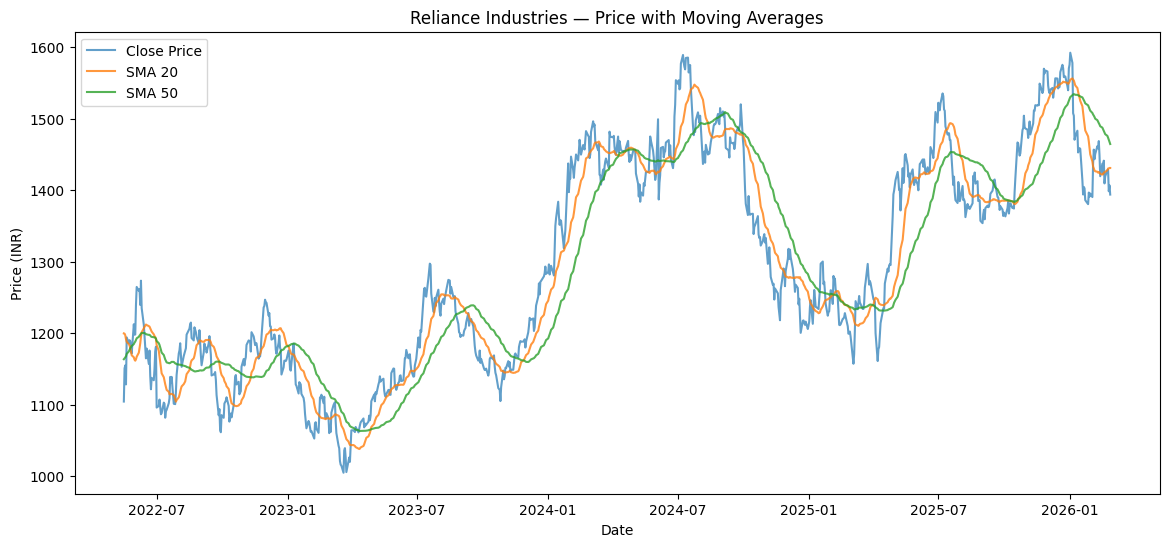

In [61]:
plt.figure(figsize=(14, 6))
plt.plot(df['Close'], label='Close Price', alpha=0.7)
plt.plot(df['SMA_20'], label='SMA 20', alpha=0.8)
plt.plot(df['SMA_50'], label='SMA 50', alpha=0.8)
plt.title('Reliance Industries — Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend()
plt.show()

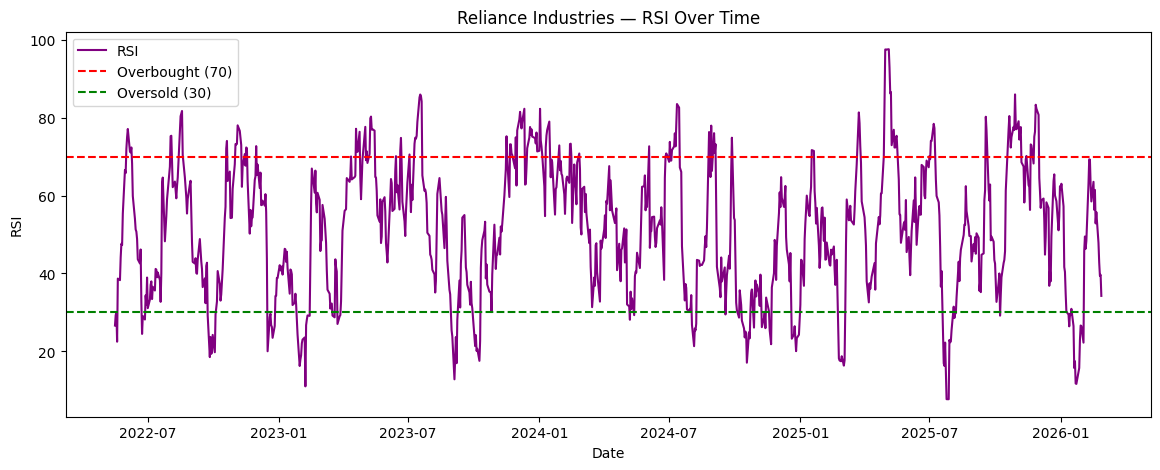

In [62]:
plt.figure(figsize=(14, 5))
plt.plot(df['RSI'], label='RSI', color='purple')
plt.axhline(70, color='red', linestyle='--', label='Overbought (70)')
plt.axhline(30, color='green', linestyle='--', label='Oversold (30)')
plt.title('Reliance Industries — RSI Over Time')
plt.xlabel('Date')
plt.ylabel('RSI')
plt.legend()
plt.show()

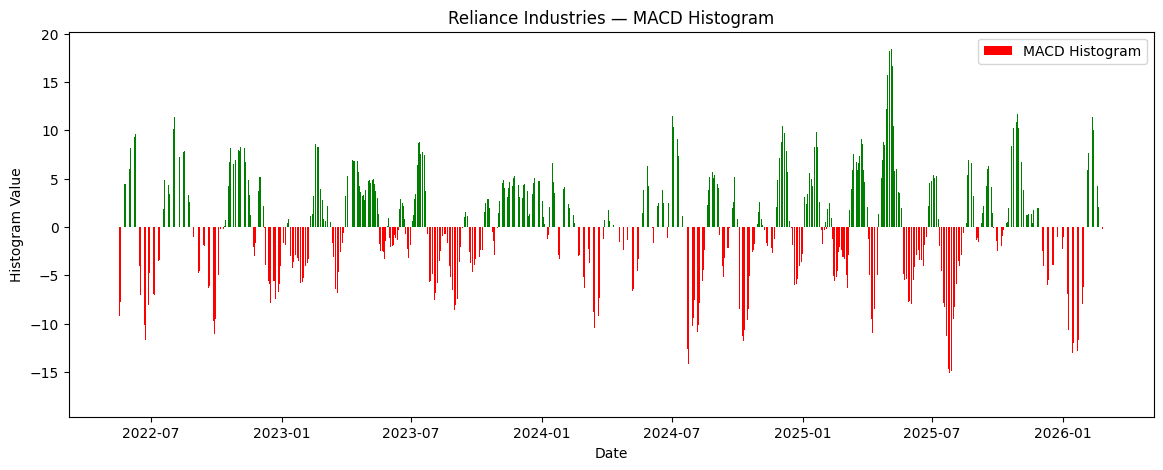

In [63]:
plt.figure(figsize=(14, 5))
plt.bar(df.index, df['MACD_Histogram'], 
        color=df['MACD_Histogram'].apply(lambda x: 'green' if x > 0 else 'red'),
        label='MACD Histogram')
plt.title('Reliance Industries — MACD Histogram')
plt.xlabel('Date')
plt.ylabel('Histogram Value')
plt.legend()
plt.show()

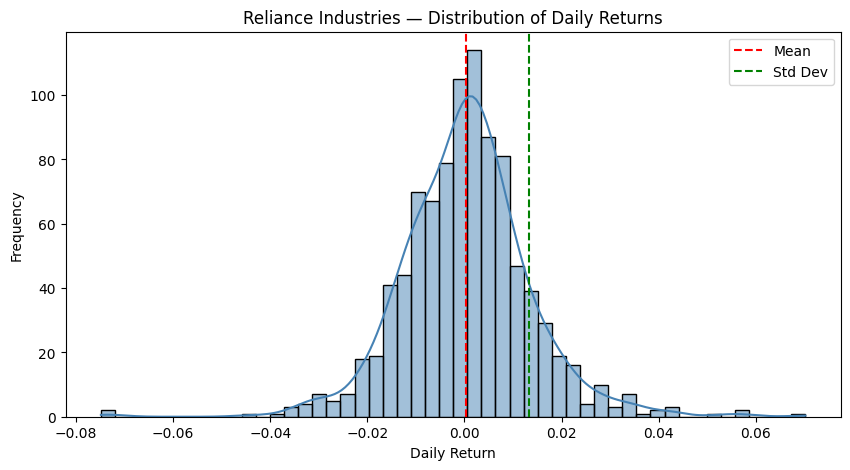

In [64]:
daily_return = df['Close'].pct_change().dropna()

plt.figure(figsize=(10, 5))
sns.histplot(daily_return, bins=50, kde=True, color='steelblue')
plt.title('Reliance Industries — Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.axvline(daily_return.mean(), color='red', linestyle='--', label='Mean')
plt.axvline(daily_return.std(), color='green', linestyle='--', label='Std Dev')
plt.legend()
plt.show()

In [65]:
print(df.dtypes)

Price
Close             float64
High              float64
Low               float64
Open              float64
Volume              int64
Target              int64
SMA_20            float64
SMA_50            float64
RSI               float64
MACD              float64
Signal_Line       float64
MACD_Histogram    float64
bb_Upper          float64
bb_Lower          float64
bb_Width          float64
Momentum          float64
Volatility         object
dtype: object


In [66]:
daily_return = df['Close'].pct_change()
df['Volatility'] = daily_return.rolling(20).std()
df['Volatility'] = df['Volatility'].astype(float)

In [67]:
print(df['Volatility'].dtype)
print(df['Volatility'].head())

float64
Date
2022-05-16   NaN
2022-05-17   NaN
2022-05-18   NaN
2022-05-19   NaN
2022-05-20   NaN
Name: Volatility, dtype: float64


In [68]:
df.dropna(inplace=True)
print(df.shape)

(920, 17)


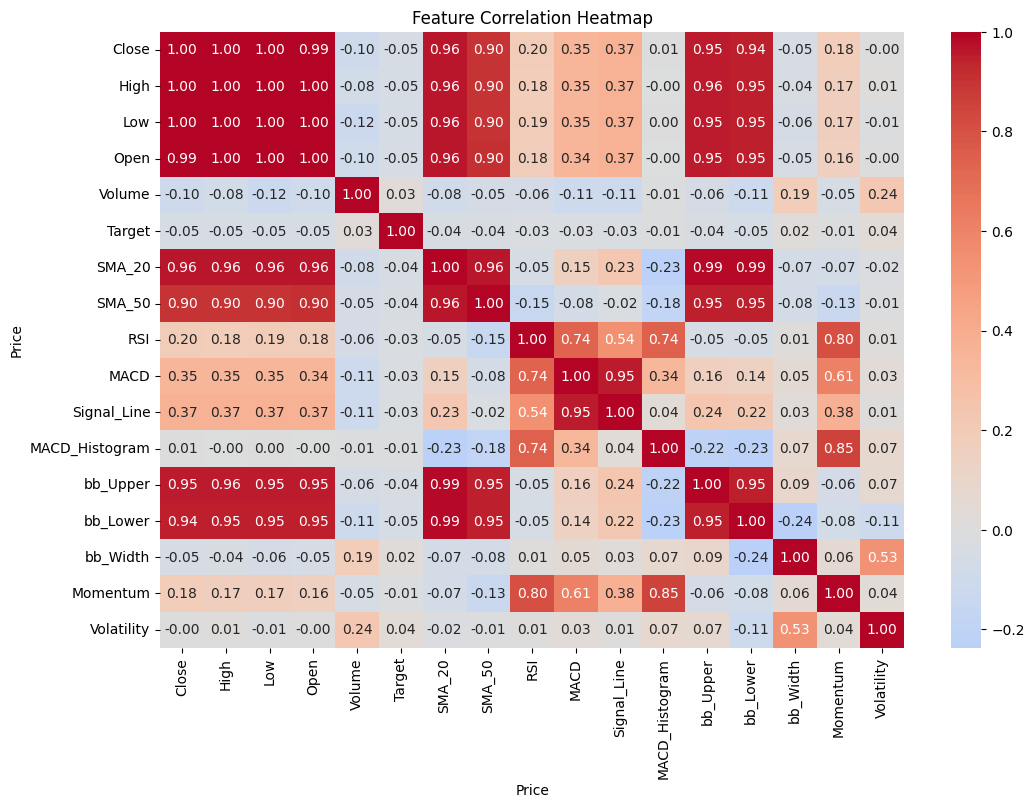

In [69]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', 
            cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

In [70]:
df.drop(['bb_Upper', 'bb_Lower'], axis=1, inplace=True)
print(df.columns.tolist())
print(df.shape)

['Close', 'High', 'Low', 'Open', 'Volume', 'Target', 'SMA_20', 'SMA_50', 'RSI', 'MACD', 'Signal_Line', 'MACD_Histogram', 'bb_Width', 'Momentum', 'Volatility']
(920, 15)


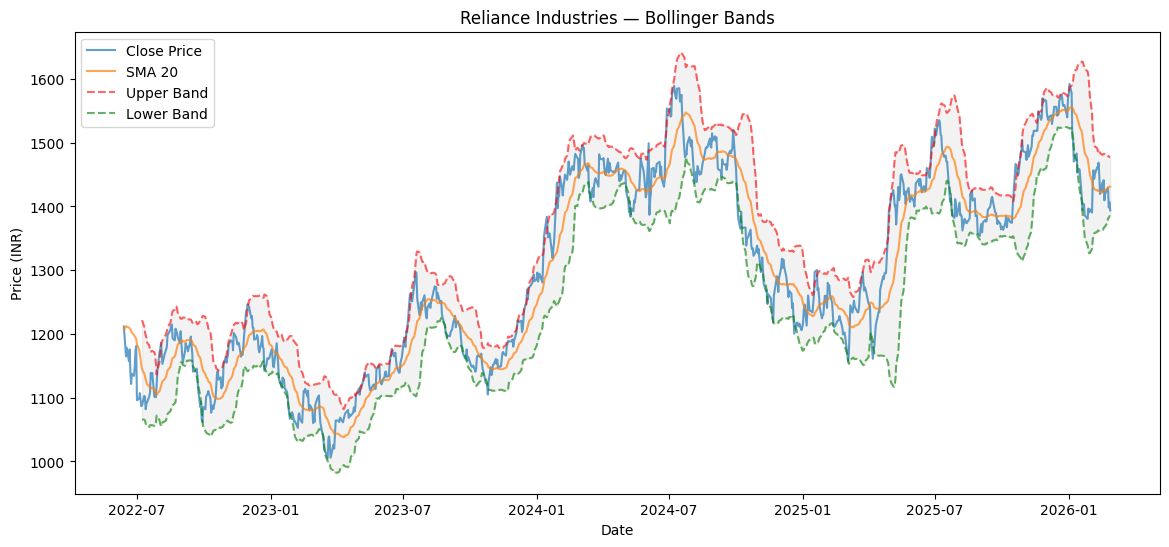

In [71]:
plt.figure(figsize=(14, 6))
plt.plot(df['Close'], label='Close Price', alpha=0.7)
plt.plot(df['SMA_20'], label='SMA 20', alpha=0.7)

# Recalculate for plotting since we dropped bb_Upper and bb_Lower
std_20 = df['Close'].rolling(20).std()
bb_upper = df['SMA_20'] + 2 * std_20
bb_lower = df['SMA_20'] - 2 * std_20

plt.plot(bb_upper, label='Upper Band', linestyle='--', color='red', alpha=0.6)
plt.plot(bb_lower, label='Lower Band', linestyle='--', color='green', alpha=0.6)
plt.fill_between(df.index, bb_upper, bb_lower, alpha=0.1, color='grey')
plt.title('Reliance Industries — Bollinger Bands')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend()
plt.show()

In [72]:
# Define features and target
features = ['Close', 'High', 'Low', 'Open', 'Volume', 
            'SMA_20', 'SMA_50', 'RSI', 'MACD', 
            'Signal_Line', 'MACD_Histogram', 'bb_Width', 
            'Momentum', 'Volatility']

X = df[features]
y = df['Target']

# Chronological split — no shuffling
split = int(len(df) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 736
Testing samples: 184


In [73]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [74]:
# Train
lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)

# Predict
lr_pred = lr_model.predict(X_test_scaled)

# Evaluate
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, lr_pred):.4f}")
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.4783
              precision    recall  f1-score   support

           0       0.50      0.74      0.59        95
           1       0.42      0.20      0.27        89

    accuracy                           0.48       184
   macro avg       0.46      0.47      0.43       184
weighted avg       0.46      0.48      0.44       184



In [75]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.5272
              precision    recall  f1-score   support

           0       0.54      0.61      0.57        95
           1       0.51      0.44      0.47        89

    accuracy                           0.53       184
   macro avg       0.53      0.52      0.52       184
weighted avg       0.53      0.53      0.52       184



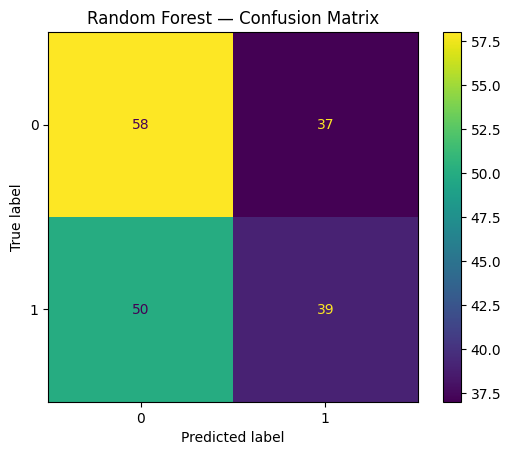

In [76]:
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred)
plt.title('Random Forest — Confusion Matrix')
plt.show()

In [77]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print(f"XGBoost Accuracy: {accuracy_score(y_test, xgb_pred):.4f}")
print(classification_report(y_test, xgb_pred))

XGBoost Accuracy: 0.5054
              precision    recall  f1-score   support

           0       0.52      0.60      0.56        95
           1       0.49      0.40      0.44        89

    accuracy                           0.51       184
   macro avg       0.50      0.50      0.50       184
weighted avg       0.50      0.51      0.50       184



In [78]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=tscv,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Accuracy: 0.5098


In [79]:
best_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=5,
    random_state=42
)

best_rf.fit(X_train, y_train)
best_rf_pred = best_rf.predict(X_test)

print(f"Tuned Random Forest Accuracy: {accuracy_score(y_test, best_rf_pred):.4f}")
print(classification_report(y_test, best_rf_pred))

Tuned Random Forest Accuracy: 0.4837
              precision    recall  f1-score   support

           0       0.50      0.66      0.57        95
           1       0.45      0.29      0.35        89

    accuracy                           0.48       184
   macro avg       0.47      0.48      0.46       184
weighted avg       0.47      0.48      0.47       184



           Feature  Importance
4           Volume    0.091505
11        bb_Width    0.077037
13      Volatility    0.076316
10  MACD_Histogram    0.072736
7              RSI    0.072680
2              Low    0.070810
12        Momentum    0.070490
3             Open    0.069581
8             MACD    0.069557
9      Signal_Line    0.068753
0            Close    0.068141
5           SMA_20    0.066811
6           SMA_50    0.063248
1             High    0.062335


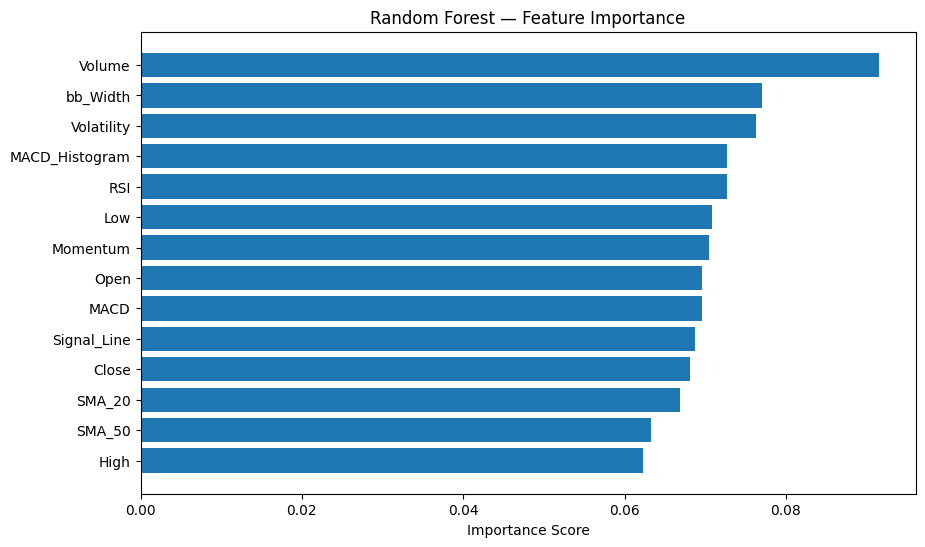

In [80]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance Score')
plt.title('Random Forest — Feature Importance')
plt.gca().invert_yaxis()
plt.show()

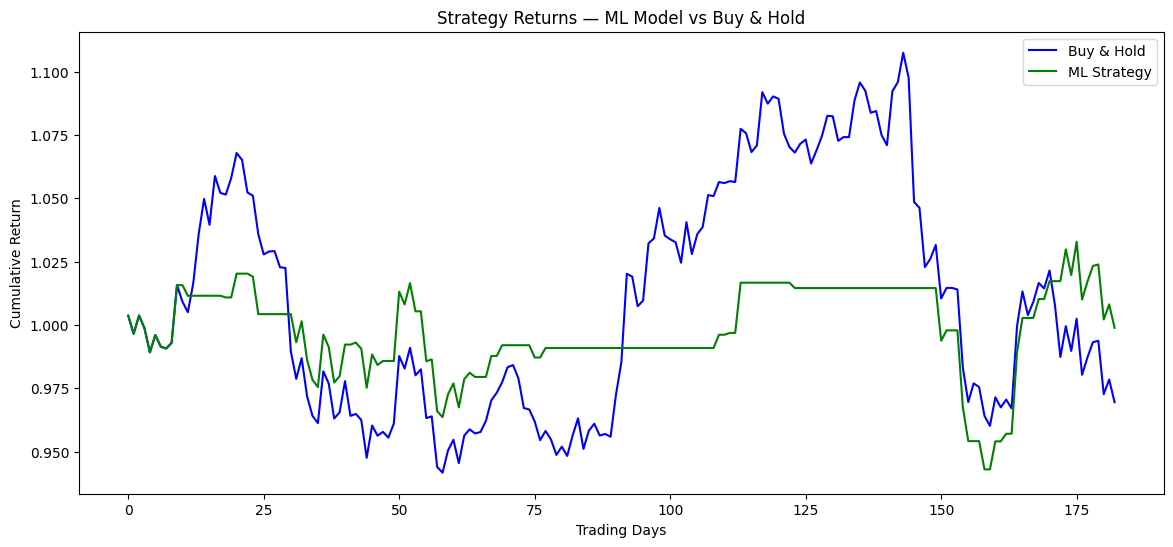

Buy & Hold Return: -3.05%
ML Strategy Return: -0.11%


In [81]:
# Get actual returns for test period
test_returns = df['Close'].pct_change().iloc[split+1:].values
rf_pred_aligned = rf_pred[:len(test_returns)]

# Strategy — buy when model predicts up, stay out when predicts down
strategy_returns = test_returns * rf_pred_aligned

# Cumulative returns
cumulative_market = (1 + test_returns).cumprod()
cumulative_strategy = (1 + strategy_returns).cumprod()

plt.figure(figsize=(14, 6))
plt.plot(cumulative_market, label='Buy & Hold', color='blue')
plt.plot(cumulative_strategy, label='ML Strategy', color='green')
plt.title('Strategy Returns — ML Model vs Buy & Hold')
plt.xlabel('Trading Days')
plt.ylabel('Cumulative Return')
plt.legend()
plt.show()

print(f"Buy & Hold Return: {(cumulative_market[-1]-1)*100:.2f}%")
print(f"ML Strategy Return: {(cumulative_strategy[-1]-1)*100:.2f}%")

In [82]:
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print(classification_report(y_test, rf_pred))
print(f"\nBuy & Hold Return: {(cumulative_market[-1]-1)*100:.2f}%")
print(f"ML Strategy Return: {(cumulative_strategy[-1]-1)*100:.2f}%")

Random Forest Accuracy: 0.5272
              precision    recall  f1-score   support

           0       0.54      0.61      0.57        95
           1       0.51      0.44      0.47        89

    accuracy                           0.53       184
   macro avg       0.53      0.52      0.52       184
weighted avg       0.53      0.53      0.52       184


Buy & Hold Return: -3.05%
ML Strategy Return: -0.11%


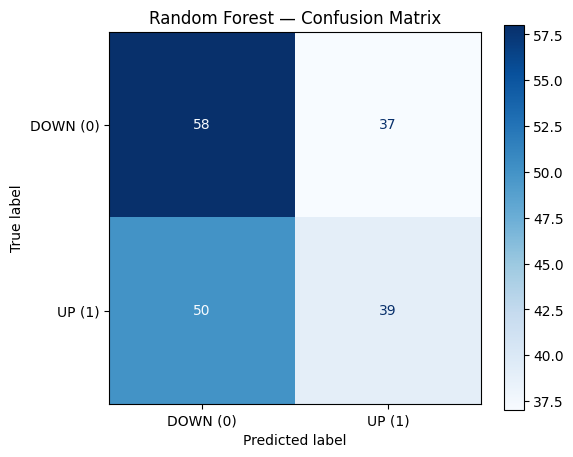

In [83]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    display_labels=['DOWN (0)', 'UP (1)'],
    cmap='Blues',
    ax=ax
)
plt.title('Random Forest — Confusion Matrix')
plt.show()